# Part 2: CNN Computer Vision Assignment
## Product Defect Classification (Normal, Scratch, Dent, Stain)
**Student:** Ravindra Hegde


In [5]:
from google.colab import files
import zipfile
import os

# Upload the zip file
print("Please upload the zipped dataset folder...")
uploaded = files.upload()

# Unzip the file
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/')
        print(f"✅ Extracted {filename}")
        break

# Set DATA_DIR
DATA_DIR = '/content/part_2_cnn_computer_vision'
print("Dataset folder:", os.listdir(DATA_DIR))

Please upload the zipped dataset folder...


Saving part_2_cnn_computer_vision.zip to part_2_cnn_computer_vision.zip
✅ Extracted part_2_cnn_computer_vision.zip
Dataset folder: ['data_dictionary.md', 'labels.csv', '.DS_Store', 'images']


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)
print("✅ Libraries imported!")

TensorFlow Version: 2.20.0
✅ Libraries imported!


Total Images: 480

Class Distribution:
 class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


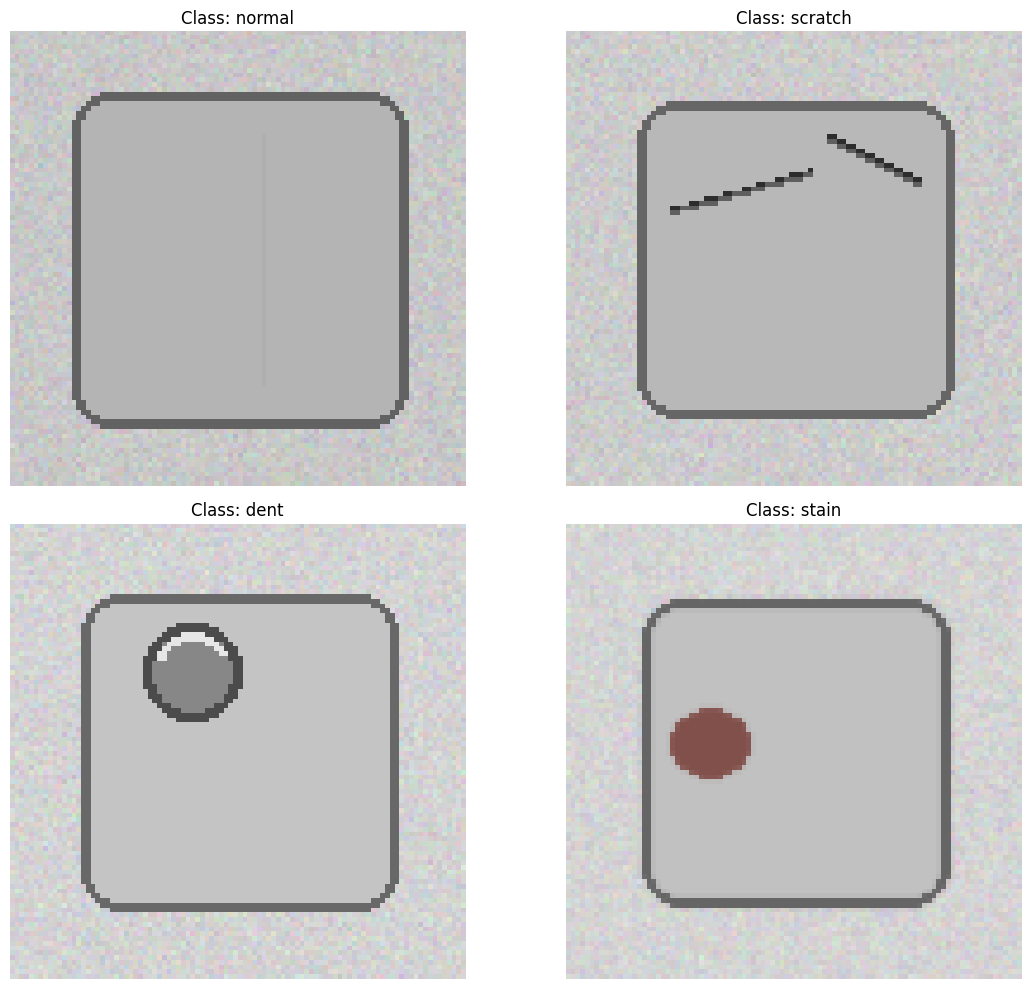

In [7]:
labels = pd.read_csv(os.path.join(DATA_DIR, 'labels.csv'))

print("Total Images:", len(labels))
print("\nClass Distribution:\n", labels['class'].value_counts())

# Show sample images
classes = ['normal', 'scratch', 'dent', 'stain']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, cls in enumerate(classes):
    sample = labels[labels['class'] == cls].iloc[0]
    img_path = os.path.join(DATA_DIR, sample['filename'])
    img = Image.open(img_path)
    axes[i//2, i%2].imshow(img)
    axes[i//2, i%2].set_title(f"Class: {cls}")
    axes[i//2, i%2].axis('off')

plt.tight_layout()
plt.show()

In [9]:
IMG_SIZE = (128, 128)
class_map = {'normal': 0, 'scratch': 1, 'dent': 2, 'stain': 3}

X = []
y = []

print("Loading images... (This may take 1-2 minutes)")

for _, row in labels.iterrows():
    img_path = os.path.join(DATA_DIR, row['filename'])
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0
    X.append(img_array)
    y.append(class_map[row['class']])

X = np.array(X)
y = to_categorical(y, num_classes=4)

print("✅ Preprocessing Completed!")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y.argmax(axis=1)
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Loading images... (This may take 1-2 minutes)
✅ Preprocessing Completed!
X shape: (480, 128, 128, 3)
y shape: (480, 4)
Training samples: 384
Testing samples: 96


In [10]:
def build_cnn():
    model = Sequential([
        Conv2D(32, (3,3), padding='same', input_shape=(128,128,3)),
        Activation('relu'),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), padding='same'),
        Activation('relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), padding='same'),
        Activation('relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(512),
        Activation('relu'),
        Dropout(0.5),

        Dense(4),
        Activation('softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,873,028 (64.37 MB)

 Trainable params: 16,873,028 (64.37 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
print("🚀 Starting Training...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    verbose=1
)
print("✅ Training Finished!")

🚀 Starting Training...
Epoch 1/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.2215 - loss: 2.3645 - val_accuracy: 0.2208 - val_loss: 1.3814
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2964 - loss: 1.3811 - val_accuracy: 0.2987 - val_loss: 1.3632
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3388 - loss: 1.3577 - val_accuracy: 0.5455 - val_loss: 1.3067
Epoch 4/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4560 - loss: 1.2559 - val_accuracy: 0.6494 - val_loss: 1.1540
Epoch 5/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5472 - loss: 1.0157 - val_accuracy: 0.6364 - val_loss: 0.9055
Epoch 6/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6482 - loss: 0.7556 - val_accuracy: 0.7013 - val_loss: 0.7437
Epoch 7/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7362 - loss: 0.5921 - val_accuracy: 0.8182 - val_loss: 0.4978
Epoch 8/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8143 - loss: 0.5005 - val_accur

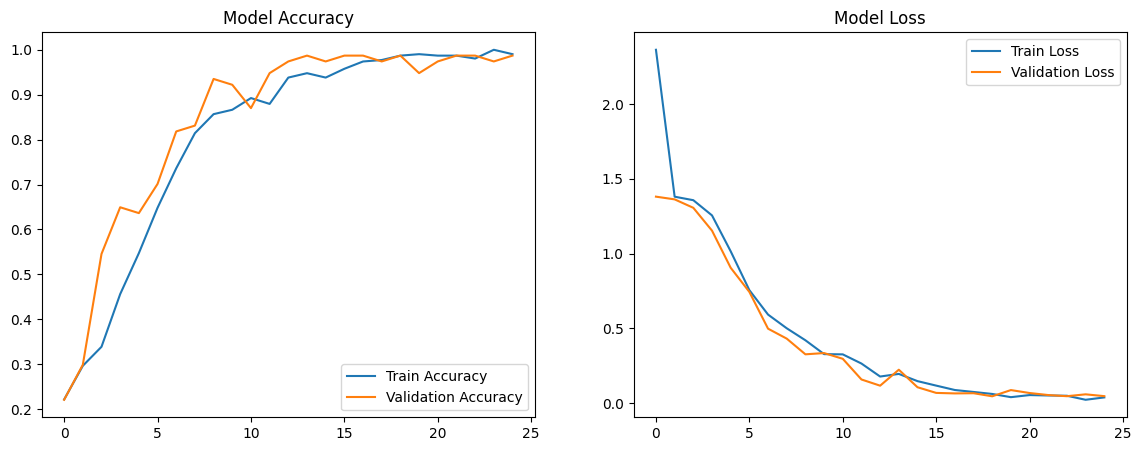


🎯 Final Test Accuracy: 0.9688 (96.88%)


In [12]:
# Plot Training History
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# Test Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 Final Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 731ms/step


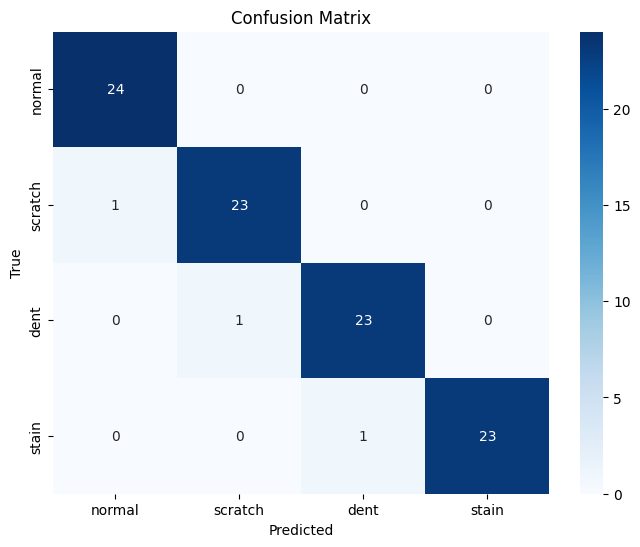


Classification Report:
              precision    recall  f1-score   support

      normal       0.96      1.00      0.98        24
     scratch       0.96      0.96      0.96        24
        dent       0.96      0.96      0.96        24
       stain       1.00      0.96      0.98        24

    accuracy                           0.97        96
   macro avg       0.97      0.97      0.97        96
weighted avg       0.97      0.97      0.97        96



In [13]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_map.keys(),
            yticklabels=class_map.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes,
                          target_names=class_map.keys()))